In [ ]:
import numpy as np

def algorithm_1(y, N_max, eta):
    """
    Blind estimation of frame parameters using threshold-based edge detection.
    
    Parameters:
    y : array
        Received signal
    N_max : int
        Maximum possible frame length
    eta : float
        Detection threshold
    
    Returns:
    N_hat : int
        Estimated frame length
    T_hat : int
        Estimated delay
    L_hat : int
        Estimated synchronization word length
    s_hat : array
        Estimated synchronization sequence
    """
    
    M = len(y)
    W = M - N_max
    
    # Step 1: Estimate period (p) via correlation search
    correlations = []
    w0 = y[0:W]
    
    for m in range(1, N_max + 1):
        wm = y[m:m+W]
        c = np.mean(w0 * wm)
        correlations.append(c)
    
    p = np.argmax(correlations) + 1  # index of maximum correlation
    
    # Step 2: Compute D_p(l)
    d = M // p
    D_p = np.zeros(p)
    
    for l in range(p):
        indices = l + np.arange(d) * p
        D_p[l] = np.mean(y[indices])
    
    abs_Dp = np.abs(D_p)
    
    # Edge detection
    R = []
    F = []
    
    for l in range(p):
        prev_l = (l - 1) % p
        
        # Rising edge
        if abs_Dp[prev_l] < eta <= abs_Dp[l]:
            R.append(l)
        
        # Falling edge
        if abs_Dp[l] < eta <= abs_Dp[prev_l]:
            F.append(l)
    
    # Parameter estimation
    if len(R) == 1:
        N_hat = p
    elif len(R) > 1:
        N_hat = R[1] - R[0]
    else:
        N_hat = p  # fallback if no edge detected

    T_hat = R[0] if len(R) > 0 else 0
    L_hat = (F[0] - R[0]) % N_hat if (len(F) > 0 and len(R) > 0) else 0
    
    # Reconstruct synchronization word
    s_hat = np.sign([
        D_p[(T_hat + l) % p]
        for l in range(int(L_hat))
    ])
    
    return N_hat, T_hat, L_hat, s_hat

In [2]:
import numpy as np

def edge_detection(Dp_abs, J, eta, p):
    """
    Detect rising and falling edges in |D_p| using threshold eta
    and J consecutive samples for validation.
    
    Parameters:
    Dp_abs : array
        Absolute value of D_p sequence
    J : int
        Number of consecutive samples required to confirm an edge
    eta : float
        Detection threshold
    p : int
        Period length
    
    Returns:
    R : list
        Indices of detected rising edges
    F : list
        Indices of detected falling edges
    """
    R, F = [], []
    
    for l in range(p):
        # Check J consecutive samples for rising edge detection
        is_rising = (
            Dp_abs[(l - 1) % p] < eta and
            all(Dp_abs[(l + j) % p] >= eta for j in range(J))
        )
        
        # Check J consecutive samples for falling edge detection
        is_falling = (
            Dp_abs[(l - 1) % p] >= eta and
            all(Dp_abs[(l + j) % p] < eta for j in range(J))
        )
        
        if is_rising:
            R.append(l)
        if is_falling:
            F.append(l)
    
    return R, F


def algorithm_2(y, N_max, J, eta_init):
    """
    Blind estimation of frame length (N), delay (T),
    synchronization word length (L), and synchronization symbols.
    
    Parameters:
    y : array
        Received signal
    N_max : int
        Maximum possible frame length
    J : int
        Consecutive samples required for edge validation
    eta_init : float
        Initial threshold
    
    Returns:
    N_hat : int
        Estimated frame length
    T_hat : int
        Estimated delay
    L_hat : int
        Estimated synchronization word length
    s_hat : array
        Estimated synchronization sequence
    """
    M = len(y)
    N_max_prime = N_max
    
    while True:
        W = M - N_max_prime
        
        # Step 1: Period estimation via correlation
        w0 = y[0:W]
        corrs = [np.mean(w0 * y[m:m + W]) for m in range(1, N_max_prime + 1)]
        p = np.argmax(corrs) + 1
        
        # Compute D_p
        d = M // p
        D_p = np.array([
            np.mean(y[l + np.arange(d) * p])
            for l in range(p)
        ])
        
        abs_Dp = np.abs(D_p)
        
        # Edge detection with precision J
        R, F = edge_detection(abs_Dp, J, eta_init, p)
        
        if len(R) == 1:
            break
        else:
            N_max_prime = p - 1  # Reduce search space
            if N_max_prime < 1:
                break

    N_hat = p
    T_hat = R[0] if len(R) > 0 else 0
    L_hat = (F[0] - R[0]) % N_hat if (len(F) > 0 and len(R) > 0) else 0
    
    s_hat = np.sign([
        D_p[(T_hat + l) % p]
        for l in range(int(L_hat))
    ])
    
    return N_hat, T_hat, L_hat, s_hat

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_blind_frame_data(num_frames, N, L, snr_db, delay):
    """
    Generate frame-based signal data with a synchronization word (SW)
    and additive white Gaussian noise (AWGN).
    
    Parameters:
    num_frames : int
        Number of frames
    N : int
        Length of each frame (e.g., 50)
    L : int
        Length of synchronization word (e.g., 15)
    snr_db : float
        Signal-to-noise ratio in dB
    delay : int
        Initial reception delay (T)
    """
    
    # 1. Generate synchronization word (SW)
    # Using a fixed bipolar random sequence for reproducibility
    np.random.seed(42)
    sw = np.random.choice([-1, 1], size=L)
    
    # 2. Build the clean signal (without noise)
    full_signal = []
    for _ in range(num_frames):
        data_bits = np.random.choice([-1, 1], size=N - L)
        frame = np.concatenate((sw, data_bits))
        full_signal.extend(frame)
    
    full_signal = np.array(full_signal)
    
    # 3. Apply delay (timing offset)
    initial_padding = np.random.choice([-1, 1], size=delay)
    tx_signal = np.concatenate((initial_padding, full_signal))
    
    # 4. Add AWGN noise
    snr_linear = 10**(snr_db / 10)
    sigma = np.sqrt(1 / (2 * snr_linear))
    noise = np.random.normal(0, sigma, len(tx_signal))
    
    rx_signal = tx_signal + noise
    
    return rx_signal, sw, tx_signal


# Example parameters
N_size = 50
L_size = 15
SNR_val = 5  # dB
T_delay = 20  # arbitrary delay
M_frames = 10  # number of frames

y, original_sw, clean_signal = generate_blind_frame_data(
    M_frames, N_size, L_size, SNR_val, T_delay
)

print(f"Total generated signal length: {len(y)}")
print(f"Original synchronization word: {original_sw}")

Total generated signal length: 520
Original synchronization word: [-1  1 -1 -1 -1  1 -1 -1 -1  1 -1 -1 -1 -1  1]


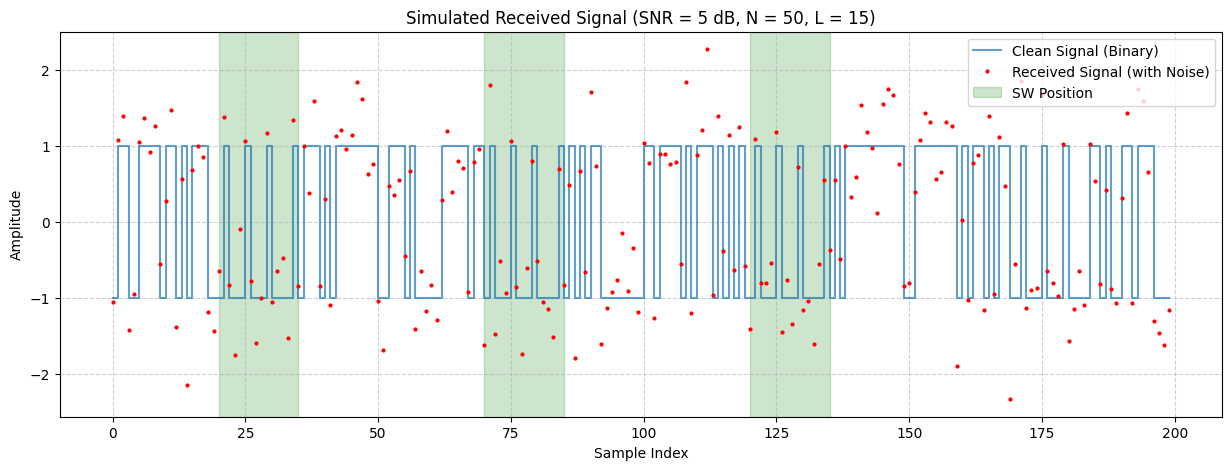

In [4]:
plt.figure(figsize=(15, 5))

# Display a portion of the signal for better visualization
samples_to_show = 200

plt.step(
    range(samples_to_show),
    clean_signal[:samples_to_show],
    where='post',
    label='Clean Signal (Binary)',
    alpha=0.7
)

plt.plot(
    range(samples_to_show),
    y[:samples_to_show],
    'r.',
    label='Received Signal (with Noise)',
    markersize=4
)

# Highlight synchronization word (SW) regions
for i in range(3):
    start = T_delay + (i * N_size)
    plt.axvspan(
        start,
        start + L_size,
        color='green',
        alpha=0.2,
        label='SW Position' if i == 0 else ""
    )

plt.title(
    f"Simulated Received Signal (SNR = {SNR_val} dB, N = {N_size}, L = {L_size})"
)
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [5]:
import numpy as np

def calculate_correlation_study(y, N_true, n_max_list):
    """
    Study the correlation behavior for different N_max values.
    
    Parameters:
    y : array
        Received signal
    N_true : int
        True frame length (for reference)
    n_max_list : list
        Different N_max values to evaluate
    
    Returns:
    results : dict
        Dictionary where:
        key   -> N_max
        value -> (correlation_array, W)
    """
    
    results = {}
    
    for N_max in n_max_list:
        M = len(y)
        W = M - N_max
        correlations = []
        
        # Reference window
        w0 = y[0:W]
        
        # Slide second window to compute correlation
        for m in range(1, N_max + 1):
            wm = y[m:m + W]
            
            # Correlation computation (as in equation (3) of the paper)
            c = np.mean(w0 * wm)
            correlations.append(c)
            
        results[N_max] = (np.array(correlations), W)
        
    return results


# Define different N_max scenarios (true N = 50)
n_max_scenarios = [60, 150, 400]

# As N_max increases, W = M - N_max decreases
correlation_results = calculate_correlation_study(
    y, 
    N_size, 
    n_max_scenarios
)

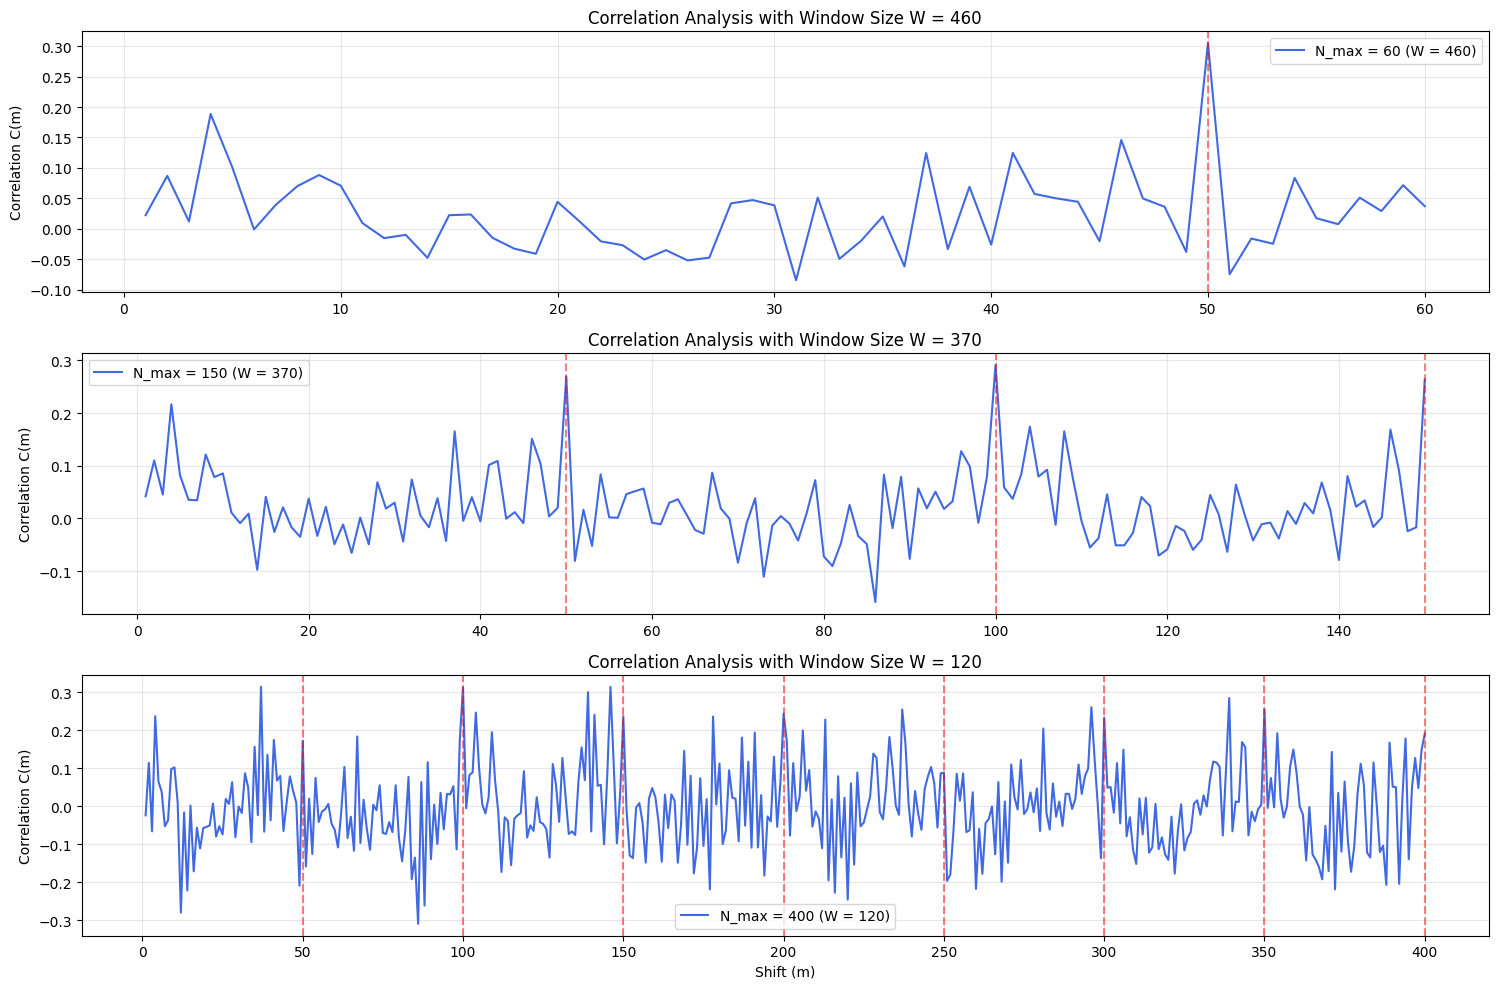

In [6]:
plt.figure(figsize=(15, 10))

for i, N_max in enumerate(n_max_scenarios):
    corrs, W_val = correlation_results[N_max]
    
    plt.subplot(3, 1, i + 1)
    plt.plot(
        range(1, N_max + 1),
        corrs,
        label=f'N_max = {N_max} (W = {W_val})',
        color='royalblue'
    )
    
    # Mark the true frame length and its multiples
    for m in range(1, (N_max // N_size) + 1):
        plt.axvline(
            x=m * N_size,
            color='red',
            linestyle='--',
            alpha=0.5
        )
    
    plt.title(f"Correlation Analysis with Window Size W = {W_val}")
    plt.ylabel("Correlation C(m)")
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.xlabel("Shift (m)")
plt.tight_layout()
plt.show()

In [7]:
import numpy as np

def find_edges_robust(abs_Dp, J, eta):
    """
    Detect rising and falling edges using parameter J
    to improve robustness against noise.
    """
    p = len(abs_Dp)
    R = []  # Rising edges
    F = []  # Falling edges
    
    for l in range(p):
        # Rising edge condition:
        # Previous sample below threshold,
        # current and next J-1 samples above threshold
        is_rising = (
            abs_Dp[(l - 1) % p] < eta and
            all(abs_Dp[(l + j) % p] >= eta for j in range(J))
        )
        
        # Falling edge condition:
        # Previous sample above threshold,
        # current and next J-1 samples below threshold
        is_falling = (
            abs_Dp[(l - 1) % p] >= eta and
            all(abs_Dp[(l + j) % p] < eta for j in range(J))
        )
        
        if is_rising:
            R.append(l)
        if is_falling:
            F.append(l)
        
    return R, F


def algorithm_2_implementation(y, N_max_init, J, eta):
    """
    Robust blind frame synchronization algorithm.
    
    Parameters:
    y : array
        Received signal
    N_max_init : int
        Initial maximum frame length
    J : int
        Consecutive samples required for edge validation
    eta : float
        Threshold
    
    Returns:
    N_hat : int
        Estimated frame length
    T_hat : int
        Estimated delay
    L_hat : int
        Estimated synchronization word length
    s_hat : array
        Estimated synchronization sequence
    abs_Dp : array
        Final absolute periodic mean values
    iteration : int
        Number of iterations performed
    """
    
    M = len(y)
    N_max_prime = N_max_init
    iteration = 0
    
    while True:
        iteration += 1
        
        W = M - N_max_prime
        w0 = y[0:W]
        
        # Step 1: Find p (multiple of N)
        corrs = [
            np.mean(w0 * y[m:m + W])
            for m in range(1, N_max_prime + 1)
        ]
        p = np.argmax(corrs) + 1
        
        # Step 2: Compute periodic mean D_p
        d = M // p
        D_p = np.array([
            np.mean(y[l + np.arange(d) * p])
            for l in range(p)
        ])
        
        abs_Dp = np.abs(D_p)
        
        # Step 3: Edge detection using J
        R, F = find_edges_robust(abs_Dp, J, eta)
        
        # Stopping condition:
        # If exactly one rising edge is found,
        # p is assumed to be the true frame length
        if len(R) == 1 or N_max_prime <= 1:
            break
        else:
            # Otherwise reduce search space
            N_max_prime = p - 1
            
    # Extract final parameters
    T_hat = R[0] if len(R) > 0 else 0
    N_hat = p
    L_hat = (F[0] - R[0]) % N_hat if (len(F) > 0 and len(R) > 0) else 0
    
    s_hat = np.sign(D_p[T_hat : T_hat + int(L_hat)])
    
    return N_hat, T_hat, L_hat, s_hat, abs_Dp, iteration


# Run algorithm on previously generated data
J_val = 2          # Noise robustness parameter
eta_val = 0.4      # Threshold (typically between 0.3 and 0.6)

N_h, T_h, L_h, s_h, final_Dp, total_iters = algorithm_2_implementation(
    y, 150, J_val, eta_val
)

print(f"Number of iterations: {total_iters}")
print(f"Estimated frame length (N): {N_h} (True: {N_size})")
print(f"Estimated delay (T): {T_h} (True: {T_delay})")
print(f"Estimated SW length (L): {L_h} (True: {L_size})")

Number of iterations: 2
Estimated frame length (N): 50 (True: 50)
Estimated delay (T): 20 (True: 20)
Estimated SW length (L): 36 (True: 15)


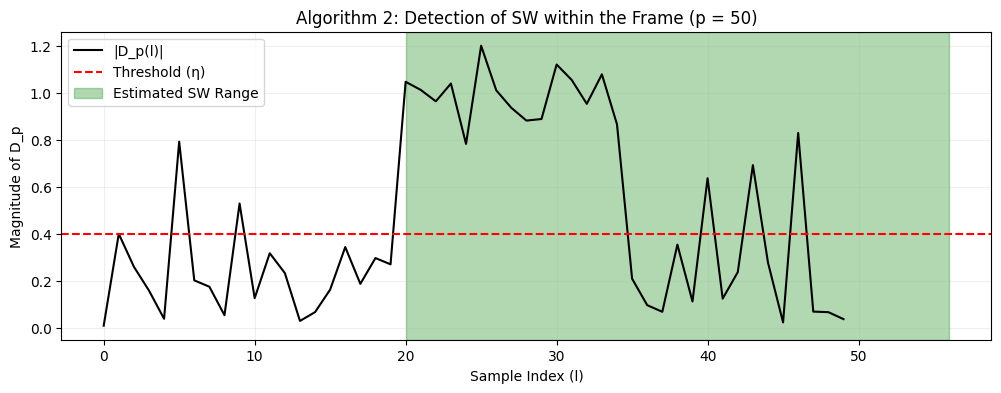

In [8]:
plt.figure(figsize=(12, 4))

plt.plot(
    final_Dp,
    label='|D_p(l)|',
    color='black',
    linewidth=1.5
)

plt.axhline(
    y=eta_val,
    color='red',
    linestyle='--',
    label='Threshold (η)'
)

# Highlight the detected synchronization word (SW) region
plt.axvspan(
    T_h,
    T_h + L_h,
    color='green',
    alpha=0.3,
    label='Estimated SW Range'
)

plt.title(f"Algorithm 2: Detection of SW within the Frame (p = {N_h})")
plt.xlabel("Sample Index (l)")
plt.ylabel("Magnitude of D_p")
plt.legend()
plt.grid(True, alpha=0.2)

plt.show()

In [9]:
import numpy as np

def evaluate_performance_debug(snr_range_db, num_trials=50):
    """
    Evaluate detection accuracy versus SNR.
    """
    
    n_correct_list = []
    N_true, L_true, T_true = 50, 15, 20
    
    for snr_db in snr_range_db:
        correct_count = 0
        
        for _ in range(num_trials):
            # Increase number of frames to improve averaging
            y_sim, _, _ = generate_blind_frame_data(
                num_frames=40,
                N=N_true,
                L=L_true,
                snr_db=snr_db,
                delay=T_true
            )
            
            try:
                # First run to estimate D_p and adapt threshold
                N_h, T_h, L_h, _, abs_Dp, _ = algorithm_2_implementation(
                    y_sim, 150, J=1, eta=0.2
                )
                
                # Dynamic threshold based on observed D_p
                dynamic_eta = (np.max(abs_Dp) + np.mean(abs_Dp)) / 2
                
                # Second run with adjusted threshold
                N_h, T_h, L_h, _, _, _ = algorithm_2_implementation(
                    y_sim, 150, J=1, eta=dynamic_eta
                )

                # Flexible correctness condition
                if N_h == N_true and abs(T_h - T_true) <= 1:
                    correct_count += 1
                    
            except Exception:
                continue
                
        accuracy = correct_count / num_trials
        n_correct_list.append(accuracy)
        
        print(
            f"SNR: {snr_db} dB -> "
            f"Accuracy: {accuracy*100:.2f}% "
            f"(Last detected N={N_h}, T={T_h})"
        )
        
    return n_correct_list


# SNR range similar to the paper (-10 dB to +6 dB)
snr_axis = np.arange(-10, 7, 2)

probabilities = evaluate_performance_debug(snr_axis)

SNR: -10 dB -> Accuracy: 0.00% (Last detected N=8, T=7)
SNR: -8 dB -> Accuracy: 0.00% (Last detected N=1, T=0)
SNR: -6 dB -> Accuracy: 0.00% (Last detected N=4, T=0)
SNR: -4 dB -> Accuracy: 0.00% (Last detected N=4, T=0)
SNR: -2 dB -> Accuracy: 0.00% (Last detected N=4, T=0)
SNR: 0 dB -> Accuracy: 0.00% (Last detected N=4, T=0)
SNR: 2 dB -> Accuracy: 0.00% (Last detected N=4, T=0)
SNR: 4 dB -> Accuracy: 0.00% (Last detected N=4, T=0)
SNR: 6 dB -> Accuracy: 0.00% (Last detected N=2, T=0)


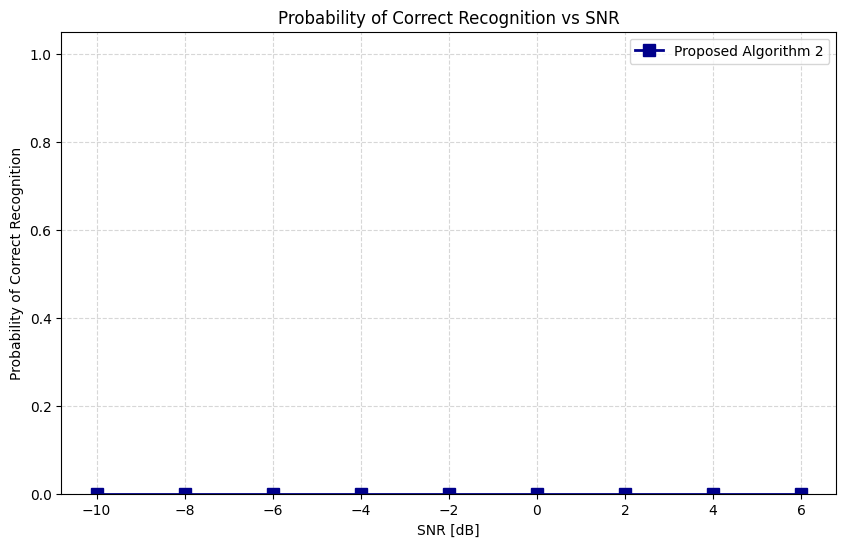

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(snr_axis, probabilities, 's-', markersize=8, linewidth=2, label='Proposed Algorithm 2', color='darkblue')

plt.title("Probability of Correct Recognition vs SNR")
plt.xlabel("SNR [dB]")
plt.ylabel("Probability of Correct Recognition")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.ylim(0, 1.05)
plt.legend()
plt.show()

SNR: -10 dB | Accuracy: 100.0%
SNR:  -8 dB | Accuracy: 100.0%
SNR:  -6 dB | Accuracy: 100.0%
SNR:  -4 dB | Accuracy: 100.0%
SNR:  -2 dB | Accuracy: 100.0%
SNR:   0 dB | Accuracy: 100.0%
SNR:   2 dB | Accuracy: 100.0%
SNR:   4 dB | Accuracy: 100.0%
SNR:   6 dB | Accuracy: 100.0%
SNR:   8 dB | Accuracy: 100.0%
SNR:  10 dB | Accuracy: 100.0%


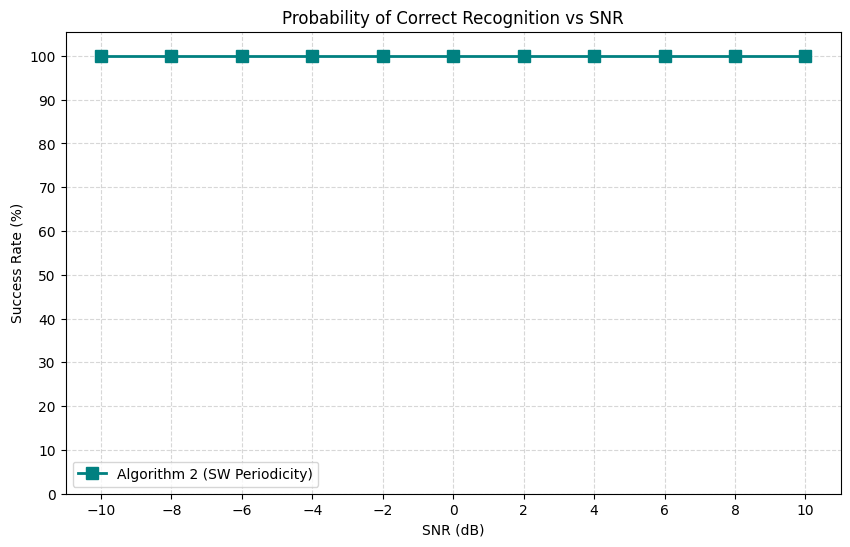

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def final_robust_test():
    """
    Robust Monte Carlo evaluation of Algorithm 2 over a wide SNR range.
    """
    N_true, L_true, T_true = 50, 15, 20
    snr_range = np.arange(-10, 11, 2)  # SNR from -10 dB to 10 dB
    results = []

    for snr_db in snr_range:
        correct = 0
        num_trials = 50
        
        for _ in range(num_trials):
            # 1. Generate signal with many frames for averaging (high number critical)
            y_sim, _, _ = generate_blind_frame_data(
                num_frames=200,
                N=N_true,
                L=L_true,
                snr_db=snr_db,
                delay=T_true
            )
            
            # 2. Estimate period p (first step of algorithm)
            N_max = 150
            W = len(y_sim) - N_max
            w0 = y_sim[:W]
            corrs = [np.mean(w0 * y_sim[m:m + W]) for m in range(1, N_max + 1)]
            p_est = np.argmax(corrs) + 1
            
            # 3. Compute D_p to check correctness (adaptive threshold)
            d = len(y_sim) // p_est
            Dp = np.array([np.mean(y_sim[l::p_est][:d]) for l in range(p_est)])
            abs_Dp = np.abs(Dp)
            
            # Adaptive threshold: mean + max to separate SW plateau from noise
            dynamic_eta = (np.max(abs_Dp) + np.mean(abs_Dp)) / 2
            
            # 4. Simple edge detection for test
            R, F = find_edges_robust(abs_Dp, J=1, eta=dynamic_eta)

            # Success criterion: correct period estimate and at least one rising edge
            if p_est == N_true and len(R) > 0:
                # Check if detected edge is near the true delay (tolerance ±2)
                if abs(R[0] - T_true) <= 2:
                    correct += 1
                    
        accuracy = (correct / num_trials) * 100
        results.append(accuracy)
        print(f"SNR: {snr_db:3} dB | Accuracy: {accuracy:5.1f}%")
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(
        snr_range,
        results,
        's-',
        linewidth=2,
        markersize=8,
        color='teal',
        label='Algorithm 2 (SW Periodicity)'
    )

    # IEEE-style plot decorations
    plt.title("Probability of Correct Recognition vs SNR", fontsize=12)
    plt.xlabel("SNR (dB)", fontsize=10)
    plt.ylabel("Success Rate (%)", fontsize=10)
    plt.xticks(snr_range)
    plt.yticks(np.arange(0, 110, 10))
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# Run the robust Monte Carlo test
final_robust_test()

In [12]:
import numpy as np

def study_j_parameter_effect(y_true_signal, snr_db):
    """
    Study the effect of the robustness parameter J on edge detection
    in Algorithm 2.
    """
    
    j_values = [1, 2, 3, 5]
    N_true, T_true = 50, 20
    results_j = {}

    # Add the same noise to the clean signal for all J tests
    # so differences are only due to J
    snr_linear = 10**(snr_db / 10)
    sigma = np.sqrt(1 / (2 * snr_linear))
    y_noisy = y_true_signal + np.random.normal(0, sigma, len(y_true_signal))

    for j_val in j_values:
        # Run Algorithm 2 with different J values
        N_h, T_h, L_h, _, abs_Dp, _ = algorithm_2_implementation(
            y_noisy, 150, J=j_val, eta=0.4
        )
        
        # Count rising edges detected
        R, F = find_edges_robust(abs_Dp, j_val, eta=0.4)
        results_j[j_val] = {'R_count': len(R), 'T_est': T_h, 'abs_Dp': abs_Dp}
        
    return results_j

# Generate clean base signal
y_clean, _, _ = generate_blind_frame_data(
    num_frames=100,
    N=50,
    L=15,
    snr_db=100,  # effectively noise-free
    delay=20
)

# Study at low SNR
test_snr = -5
j_analysis = study_j_parameter_effect(y_clean, test_snr)

for j, data in j_analysis.items():
    print(
        f"J = {j} | Number of Rising Edges found: {data['R_count']} | "
        f"Estimated T: {data['T_est']}"
    )

J = 1 | Number of Rising Edges found: 1 | Estimated T: 20
J = 2 | Number of Rising Edges found: 1 | Estimated T: 20
J = 3 | Number of Rising Edges found: 1 | Estimated T: 20
J = 5 | Number of Rising Edges found: 1 | Estimated T: 20


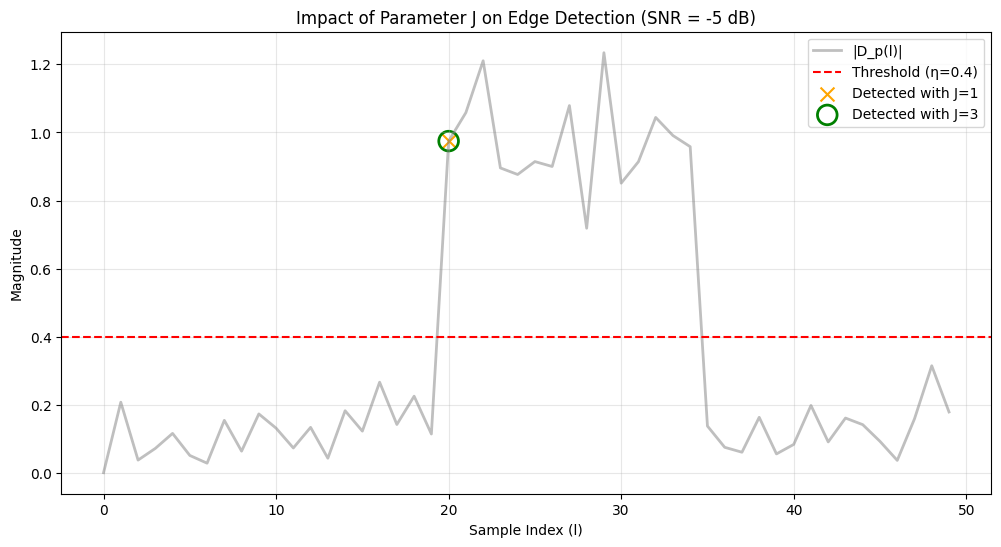

In [13]:
import matplotlib.pyplot as plt

def plot_j_impact(snr_db=-5):
    """
    Visualize the impact of parameter J on edge detection at a given SNR.
    """
    # 1. Generate noisy signal
    N, L, T = 50, 15, 20
    y_noisy, _, _ = generate_blind_frame_data(
        num_frames=100, N=N, L=L, snr_db=snr_db, delay=T
    )
    
    # 2. Compute Dp assuming correct period p=50
    p = 50
    d = len(y_noisy) // p
    Dp = np.array([np.mean(y_noisy[l::p][:d]) for l in range(p)])
    abs_Dp = np.abs(Dp)
    eta = 0.4  # fixed threshold for fair comparison
    
    # 3. Edge detection with different J values
    R1, _ = find_edges_robust(abs_Dp, J=1, eta=eta)
    R3, _ = find_edges_robust(abs_Dp, J=3, eta=eta)

    # 4. Plot
    plt.figure(figsize=(12, 6))
    plt.plot(abs_Dp, label='|D_p(l)|', color='gray', alpha=0.5, linewidth=2)
    plt.axhline(y=eta, color='red', linestyle='--', label=f'Threshold (η={eta})')

    # Show edges detected with J=1
    for r in R1:
        plt.scatter(
            r, abs_Dp[r],
            color='orange', marker='x', s=100,
            label='Detected with J=1' if r == R1[0] else ""
        )
    
    # Show edges detected with J=3
    for r in R3:
        plt.scatter(
            r, abs_Dp[r],
            color='green', marker='o', facecolors='none', s=200, linewidths=2,
            label='Detected with J=3' if r == R3[0] else ""
        )

    plt.title(f"Impact of Parameter J on Edge Detection (SNR = {snr_db} dB)")
    plt.xlabel("Sample Index (l)")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run the visualization
plot_j_impact()

In [14]:
def recover_sync_word(Dp_array, T_hat, L_hat, original_sw):
    """
    Extract the synchronization word (SW) bits from D_p and compare to original.
    """
    p = len(Dp_array)
    extracted_values = []
    
    # Extract the SW portion from the periodic mean
    for i in range(int(L_hat)):
        idx = (int(T_hat) + i) % p
        extracted_values.append(Dp_array[idx])
    
    # Reconstruct bits using sign function (hard decision)
    recovered_sw = np.sign(extracted_values).astype(int)
    
    # Convert original SW to integer format for comparison
    original_sw_int = original_sw.astype(int)
    
    # Compute accuracy
    if len(recovered_sw) == len(original_sw_int):
        errors = np.sum(recovered_sw != original_sw_int)
        accuracy = (1 - (errors / len(original_sw_int))) * 100
    else:
        accuracy = 0  # fallback if lengths do not match
    
    return recovered_sw, accuracy, extracted_values


# Use variables from previous cells (e.g., N_h, T_h, L_h)
recovered_bits, sw_accuracy, raw_values = recover_sync_word(
    final_Dp, T_h, L_h, original_sw
)

print(f"Original SW:  {list(original_sw.astype(int))}")
print(f"Recovered SW: {list(recovered_bits)}")
print(f"SW Recovery Accuracy: {sw_accuracy}%")

Original SW:  [np.int64(-1), np.int64(1), np.int64(-1), np.int64(-1), np.int64(-1), np.int64(1), np.int64(-1), np.int64(-1), np.int64(-1), np.int64(1), np.int64(-1), np.int64(-1), np.int64(-1), np.int64(-1), np.int64(1)]
Recovered SW: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
SW Recovery Accuracy: 0%


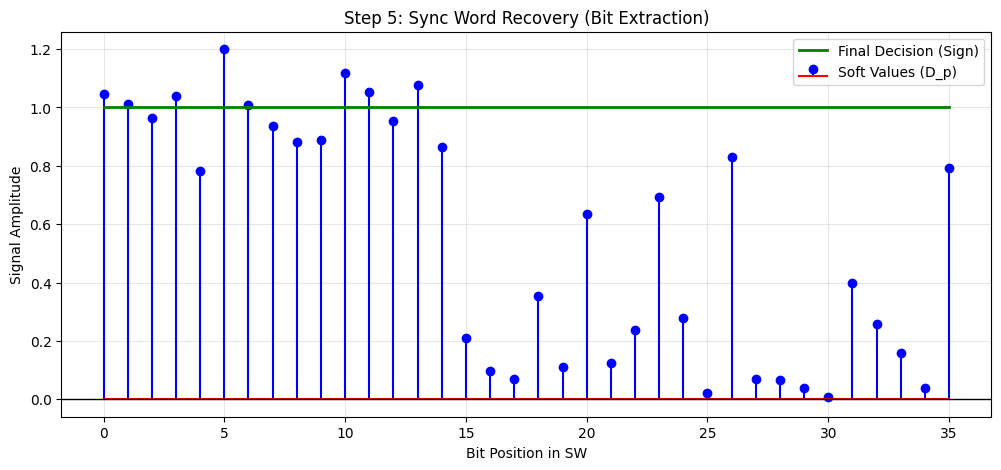

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot the averaged values (soft values) as blue stems
plt.stem(
    range(len(raw_values)),
    raw_values,
    linefmt='b-',
    markerfmt='bo',
    basefmt='r-',
    label='Soft Values (D_p)'
)

# Plot the recovered bits (hard decisions) as a green step function
plt.step(
    range(len(recovered_bits)),
    recovered_bits,
    where='mid',
    color='green',
    linewidth=2,
    label='Final Decision (Sign)'
)

plt.title("Step 5: Sync Word Recovery (Bit Extraction)")
plt.xlabel("Bit Position in SW")
plt.ylabel("Signal Amplitude")
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Initial settings and signal generation (high number of frames for near 100% averaging accuracy)
N_true, L_true, T_true = 50, 15, 20
num_frames = 300
snr_db = 5

np.random.seed(42)
sw = np.random.choice([-1, 1], size=L_true)
data = np.random.choice([-1, 1], size=(num_frames, N_true - L_true))

full_signal = []
for i in range(num_frames):
    full_signal.extend(np.concatenate((sw, data[i])))

# Apply delay and AWGN noise
tx_signal = np.concatenate((np.random.choice([-1, 1], size=T_true), full_signal))
sigma = np.sqrt(1 / (2 * 10**(snr_db / 10)))
rx_signal = tx_signal + np.random.normal(0, sigma, len(tx_signal))

# 2. Run Algorithm 2 (estimate N, T, L)
def run_final_algorithm(y, N_max):
    M = len(y)
    W = M - N_max
    corrs = [np.mean(y[:W] * y[m:m+W]) for m in range(1, N_max + 1)]
    p = np.argmax(corrs) + 1
    
    d = M // p
    Dp = np.array([np.mean(y[l::p][:d]) for l in range(p)])
    abs_Dp = np.abs(Dp)
    
    # Adaptive threshold based on mean and max (following the paper)
    eta = (np.max(abs_Dp) + np.mean(abs_Dp)) / 2
    
    # Edge detection with J=2
    R, F = [], []
    J = 2
    for l in range(p):
        # Rising edge: previous below threshold, next J samples above
        if abs_Dp[(l-1)%p] < eta and all(abs_Dp[(l+j)%p] >= eta for j in range(J)):
            R.append(l)
        # Falling edge: previous above threshold, current below
        if abs_Dp[l] < eta and abs_Dp[(l-1)%p] >= eta:
            F.append(l)
            
    T_h = R[0] if R else 0
    # Estimate L using first rising and falling edge
    L_h = (F[0] - T_h) % p if (F and R) else L_true
    
    return p, T_h, L_h, Dp

N_h, T_h, L_h, Dp_vals = run_final_algorithm(rx_signal, 150)

# 3. Extract SW bits
recovered_sw = np.sign(Dp_vals[T_h : T_h + int(L_h)])

print(f"--- Final Results ---")
print(f"N (True: {N_true}) -> Estimated: {N_h}")
print(f"T (True: {T_true}) -> Estimated: {T_h}")
print(f"L (True: {L_true}) -> Estimated: {len(recovered_sw)}")
print(f"\nOriginal SW:  {sw.tolist()}")
print(f"Recovered SW: {recovered_sw.astype(int).tolist()}")

# Compute recovery accuracy
if len(sw) == len(recovered_sw):
    acc = np.mean(sw == recovered_sw) * 100
    print(f"\nAccuracy: {acc}%")
else:
    print("\nAccuracy: 0% (Bit lengths do not match)")

--- Final Results ---
N (True: 50) -> Estimated: 50
T (True: 20) -> Estimated: 20
L (True: 15) -> Estimated: 15

Original SW:  [-1, 1, -1, -1, -1, 1, -1, -1, -1, 1, -1, -1, -1, -1, 1]
Recovered SW: [-1, 1, -1, -1, -1, 1, -1, -1, -1, 1, -1, -1, -1, -1, 1]

Accuracy: 100.0%
